# Data Loading

## Setup

We install the `wfdb` (WaveForm DataBase) library for reading ECG signal files, and download the two metadata CSV files directly from PhysioNet: `ptbxl_database.csv` (one row per ECG recording) and `scp_statements.csv` (diagnosis code lookup table).

In [10]:
!pip install wfdb -q

!wget --no-check-certificate https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv
!wget --no-check-certificate https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv

## Downloading the Signal Records

The PTB-XL dataset contains 21,799 ECG recordings in WFDB format, organised into numbered subfolders under `records100/` (e.g. `records100/00000/`, `records100/01000/`). Each recording is stored as a pair of files:

- `.hea`: plain-text header describing sampling rate, lead names, units, and patient metadata
- `.dat`: binary file containing the raw voltage samples

The low-resolution variant (`_lr`) is sampled at **100 Hz**, giving **1,000 samples** per 10-second recording across **12 leads**. We scrape the PhysioNet directory listing for each subfolder and skip files that have already been downloaded.

In [43]:
import os
import requests
import urllib3
from bs4 import BeautifulSoup
from tqdm import tqdm

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

BASE = "https://physionet.org/files/ptb-xl/1.0.3/records100/"
SAVE_ROOT = "../data/records100"
print(os.path.abspath(SAVE_ROOT))

os.makedirs(SAVE_ROOT, exist_ok=True)

# folders = [f"{i:05d}" for i in range(0, 21001, 1000)]
folders = [
    "10000","11000","12000","13000","14000",
    "15000","16000","17000","18000","19000","20000","21000"
]

session = requests.Session()
session.verify = False

for folder in tqdm(folders, desc="Downloading folders"):
    folder_url = BASE + folder + "/"
    folder_path = os.path.join(SAVE_ROOT, folder)
    os.makedirs(folder_path, exist_ok=True)

    response = session.get(folder_url)
    soup = BeautifulSoup(response.text, "html.parser")

    files = [
        a["href"] for a in soup.find_all("a")
        if a["href"].endswith((".dat", ".hea"))
    ]

    file_pbar = tqdm(total=len(files), desc=folder, leave=False)

    for i, file in enumerate(files, 1):
        save_path = os.path.join(folder_path, file)

        if not os.path.exists(save_path):
            file_url = folder_url + file
            r = session.get(file_url, stream=True)

            with open(save_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

        # update only every 100 files OR at the end
        if i % 100 == 0 or i == len(files):
            file_pbar.update(100 if i % 100 == 0 else (len(files) % 100))

    file_pbar.close()

print("Download complete.")

## Verifying the Data

Before exploring the full dataset we do a quick sanity check: load the metadata CSV (indexed by `ecg_id`) and parse the `scp_codes` column from a raw string into a Python dict using `ast.literal_eval`. We then load one signal record with `wfdb.rdsamp()`, which returns a tuple of `(signal_array, metadata_dict)`. The signal array should have shape `(1000, 12)`, 1,000 time steps across 12 leads.

In [2]:
import pandas as pd
import wfdb
import ast

path = '../data/'  

# Check CSVs loaded
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))
print(f"Records loaded: {len(Y)}")          
# print(f"Columns: {list(Y.columns[:6])}")    # ecg_id, patient_id, age, sex...
print(f"Columns: {list(Y.columns)}")    # ecg_id, patient_id, age, sex...

# Check one signal loaded
record = wfdb.rdsamp(path + 'records100/00000/00001_lr')
print("Signal metadata:", record[1]) 
print(len(record))  # should print: 2 (signal, metadata)
signal = record[0]
print("Signal:", signal)
print(f"Signal shape: {signal.shape}")      # should print: (1000, 12)
print(f"Leads: {record[1]['sig_name']}")    # I, II, III, aVR, aVL, aVF, V1-V6

Records loaded: 21799
Columns: ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']
Signal metadata: {'fs': 100, 'sig_len': 1000, 'n_sig': 12, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], 'comments': []}
2
Signal: [[-0.119 -0.055  0.064 ... -0.026 -0.039 -0.079]
 [-0.116 -0.051  0.065 ... -0.031 -0.034 -0.074]
 [-0.12  -0.044  0.076 ... -0.028 -0.029 -0.069]
 ...
 [ 0.069  0.    -0.069 ...  0.024 -0.041 -0.058]
 [ 0.086  0.004 -0.081 ...  0.242 -0.046 -0.098]
 [ 0.022 -0.031

## Dataset Overview

We explore the overall composition of the dataset: how records are distributed across the 10 stratified folds and the demographic breakdown of patients by age and sex.

The `strat_fold` column (1–10) defines the standard reproducible split used in the PTB-XL benchmark, **folds 1–8 for training, fold 9 for validation, fold 10 for testing**.

> **Note:** Age values of `300` in the raw CSV are placeholders for unknown age and are excluded from the histogram. Sex is encoded as `0 = Male` and `1 = Female`.

Dataset shape: (21799, 28)
Total records: 21799

First few rows:
   ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human  baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True             NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True             NaN          NaN   
2  1984-11-15 12:49:10  ...               True             NaN          NaN   
3  1984-11-15 13:44:57  ...               True    , II,III,AVF          NaN   
4  1984-11-17 10:43:15  ...               True   , III,AVR,AVF          NaN   

  b

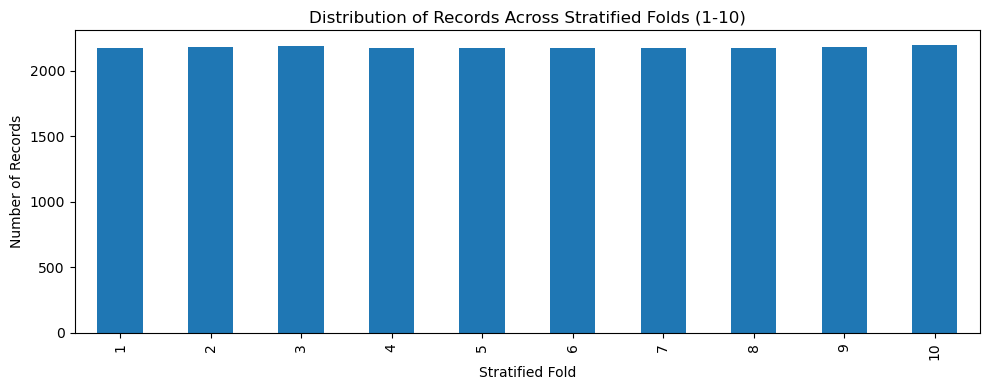

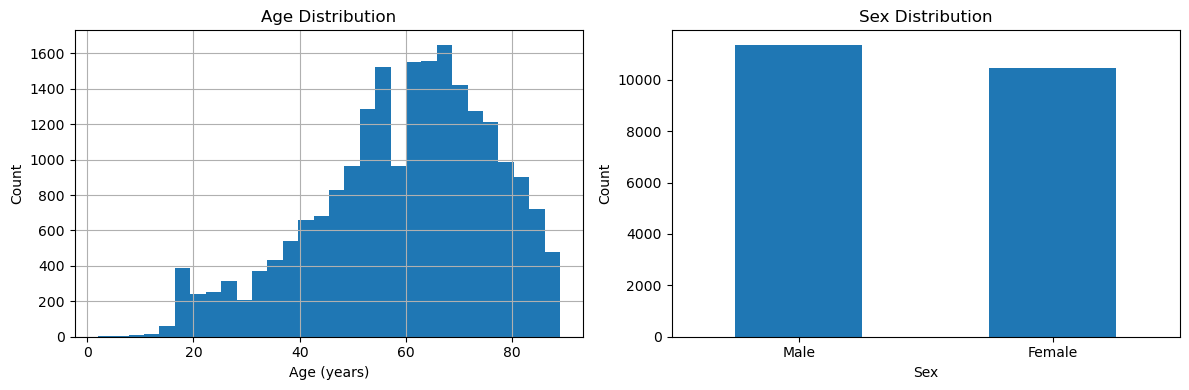

In [5]:
import matplotlib.pyplot as plt

# Load the database
db = pd.read_csv('../data/ptbxl_database.csv')

# Dataset shape and info
print(f"Dataset shape: {db.shape}")
print(f"Total records: {len(db)}")
print(f"\nFirst few rows:")
print(db.head())

print(f"\nColumn names:")
print(db.columns.tolist())

print(f"\nData types:")
print(db.dtypes)

# Summary statistics
print(f"\nAge distribution:")
print(db['age'].describe())
print(f"\nRecords with age=300 (missing): {(db['age'] == 300).sum()}")

# Sex distribution
print(f"\nSex distribution (0=Male, 1=Female):")
print(db['sex'].value_counts())

# Stratified fold distribution (train/val/test splits)
print(f"\nStratified fold distribution:")
print(db['strat_fold'].value_counts().sort_index())

# Visualize fold distribution
db['strat_fold'].value_counts().sort_index().plot(kind='bar', figsize=(10, 4))
plt.xlabel('Stratified Fold')
plt.ylabel('Number of Records')
plt.title('Distribution of Records Across Stratified Folds (1-10)')
plt.tight_layout()
plt.show()

# Age and sex distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filter out age=300 (used in PTB-XL as placeholder for missing age)
db[db['age'] < 300]['age'].hist(bins=30, ax=axes[0])
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution')

# Map 0/1 to Male/Female (PTB-XL encoding)
db['sex'].map({0: 'Male', 1: 'Female'}).value_counts().plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex Distribution')

plt.tight_layout()
plt.show()

## Diagnosis Codes: SCP Statements

Each ECG record is labelled with one or more **SCP-ECG codes** in the `scp_codes` column, stored as a dict of `{code: likelihood}` pairs (e.g. `{'NORM': 100.0}`). The `scp_statements.csv` file maps each short code to a full description and a **diagnostic class**.

There are 71 unique codes grouped into 5 classes:

| Class | Description |
|-------|-------------|
| `NORM` | Normal ECG |
| `MI` | Myocardial Infarction |
| `STTC` | ST/T Change |
| `CD` | Conduction Disturbance |
| `HYP` | Hypertrophy |

We also build a `code_to_class` lookup dict for quickly mapping any SCP code to its diagnostic class, useful later for constructing labels during model training.

Total unique diagnosis codes: 71

First few rows:
                              description  diagnostic  form  rhythm  \
NDT        non-diagnostic T abnormalities         1.0   1.0     NaN   
NST_              non-specific ST changes         1.0   1.0     NaN   
DIG                      digitalis-effect         1.0   1.0     NaN   
LNGQT                    long QT-interval         1.0   1.0     NaN   
NORM                           normal ECG         1.0   NaN     NaN   
IMI        inferior myocardial infarction         1.0   NaN     NaN   
ASMI   anteroseptal myocardial infarction         1.0   NaN     NaN   
LVH          left ventricular hypertrophy         1.0   NaN     NaN   
LAFB       left anterior fascicular block         1.0   NaN     NaN   
ISC_                non-specific ischemic         1.0   NaN     NaN   

      diagnostic_class diagnostic_subclass  \
NDT               STTC                STTC   
NST_              STTC                NST_   
DIG               STTC        

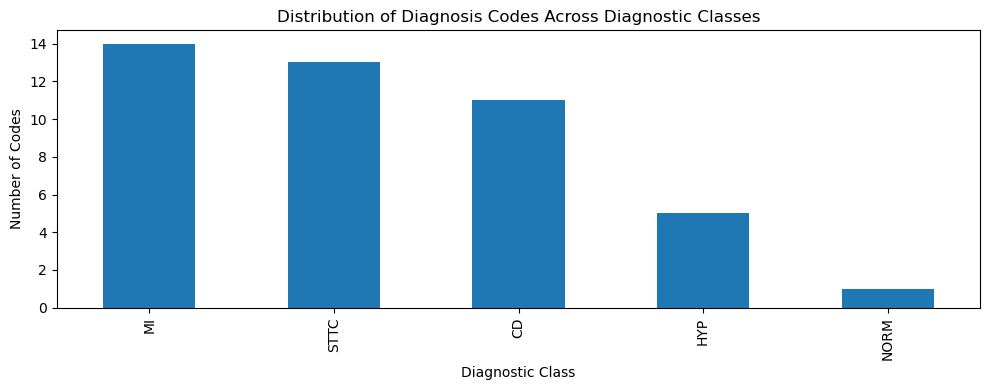


Example lookup for 'NORM':
description                           normal ECG
diagnostic                                   1.0
form                                         NaN
rhythm                                       NaN
diagnostic_class                            NORM
diagnostic_subclass                         NORM
Statement Category               Normal/abnormal
SCP-ECG Statement Description         normal ECG
AHA code                                     1.0
aECG REFID                                   NaN
CDISC Code                                   NaN
DICOM Code                               F-000B7
Name: NORM, dtype: object

Example lookup for 'IMI' (inferior myocardial infarction, diagnostic_class='MI'):
description                      inferior myocardial infarction
diagnostic                                                  1.0
form                                                        NaN
rhythm                                                      NaN
diagnostic_class   

In [17]:
# Load the SCP statements lookup table
scp = pd.read_csv('../data/scp_statements.csv', index_col=0)

print(f"Total unique diagnosis codes: {len(scp)}")
print(f"\nFirst few rows:")
print(scp.head(10))

print(f"\nDiagnostic class distribution:")
print(scp['diagnostic_class'].value_counts())

# Visualize diagnostic class distribution
scp['diagnostic_class'].value_counts().plot(kind='bar', figsize=(10, 4))
plt.xlabel('Diagnostic Class')
plt.ylabel('Number of Codes')
plt.title('Distribution of Diagnosis Codes Across Diagnostic Classes')
plt.tight_layout()
plt.show()

# Example: look up a specific code
# Note: the index contains individual SCP codes (e.g. 'NORM', 'IMI'), not class names (e.g. 'MI')
print(f"\nExample lookup for 'NORM':")
print(scp.loc['NORM'])

print(f"\nExample lookup for 'IMI' (inferior myocardial infarction, diagnostic_class='MI'):")
print(scp.loc['IMI'])

# Build a mapping from scp_code to diagnostic class for quick reference
code_to_class = scp['diagnostic_class'].to_dict()
print(f"\nCode-to-class mapping (sample):")
for code in ['NORM', 'IMI', 'AFIB', 'LBBB']:
    print(f"  {code} → {code_to_class.get(code, 'N/A')}")

## Inspecting a Single ECG Record

We load one specific record (`00001_lr`) and print its key properties: signal shape, sampling rate, duration, lead names, and units. We also look up the matching row in the metadata CSV to retrieve the patient's diagnosis codes, age, sex, and assigned fold.

Record paths in `filename_lr` are relative to the `data/` directory (e.g. `records100/00000/00001_lr`), so we prepend `path` when calling `wfdb.rdsamp()`. To find the metadata row we match on the end of the path with `.str.endswith()` since the column stores the full relative path, not just the filename.

In [8]:
import wfdb

# Load a single record
record_name = '00001_lr'
record = wfdb.rdsamp(path + 'records100/00000/' + record_name)

# Unpack the signal and metadata
signal = record[0]  # 2D numpy array (num_samples, num_leads)
meta = record[1]   # metadata dict

print(f"Record: {record_name}")
print(f"Signal shape: {signal.shape}")
print(f"  Samples: {signal.shape[0]}, Leads: {signal.shape[1]}")
print(f"Sampling rate: {meta['fs']} Hz")
print(f"Duration: {signal.shape[0] / meta['fs']:.1f} seconds")
print(f"Lead names: {meta['sig_name']}")
print(f"Units: {meta['units']}")

# Get diagnosis codes for this record
record_row = db[db['filename_lr'].str.endswith(record_name)].iloc[0]
print(f"\nDiagnosis codes: {record_row['scp_codes']}")
print(f"Age: {record_row['age']}, Sex: {record_row['sex']}")
print(f"Stratified fold: {record_row['strat_fold']}")

Record: 00001_lr
Signal shape: (1000, 12)
  Samples: 1000, Leads: 12
Sampling rate: 100 Hz
Duration: 10.0 seconds
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units: ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']

Diagnosis codes: {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
Age: 56.0, Sex: 1
Stratified fold: 3


## Visualising All 12 Leads

A standard 12-lead ECG captures the heart's electrical activity from 12 different angles simultaneously. We plot all 12 leads as separate time series over the 10-second recording window to see the full signal at once.

The leads are grouped as:
- **Limb leads:** I, II, III
- **Augmented limb leads:** AVR, AVL, AVF
- **Precordial (chest) leads:** V1, V2, V3, V4, V5, V6

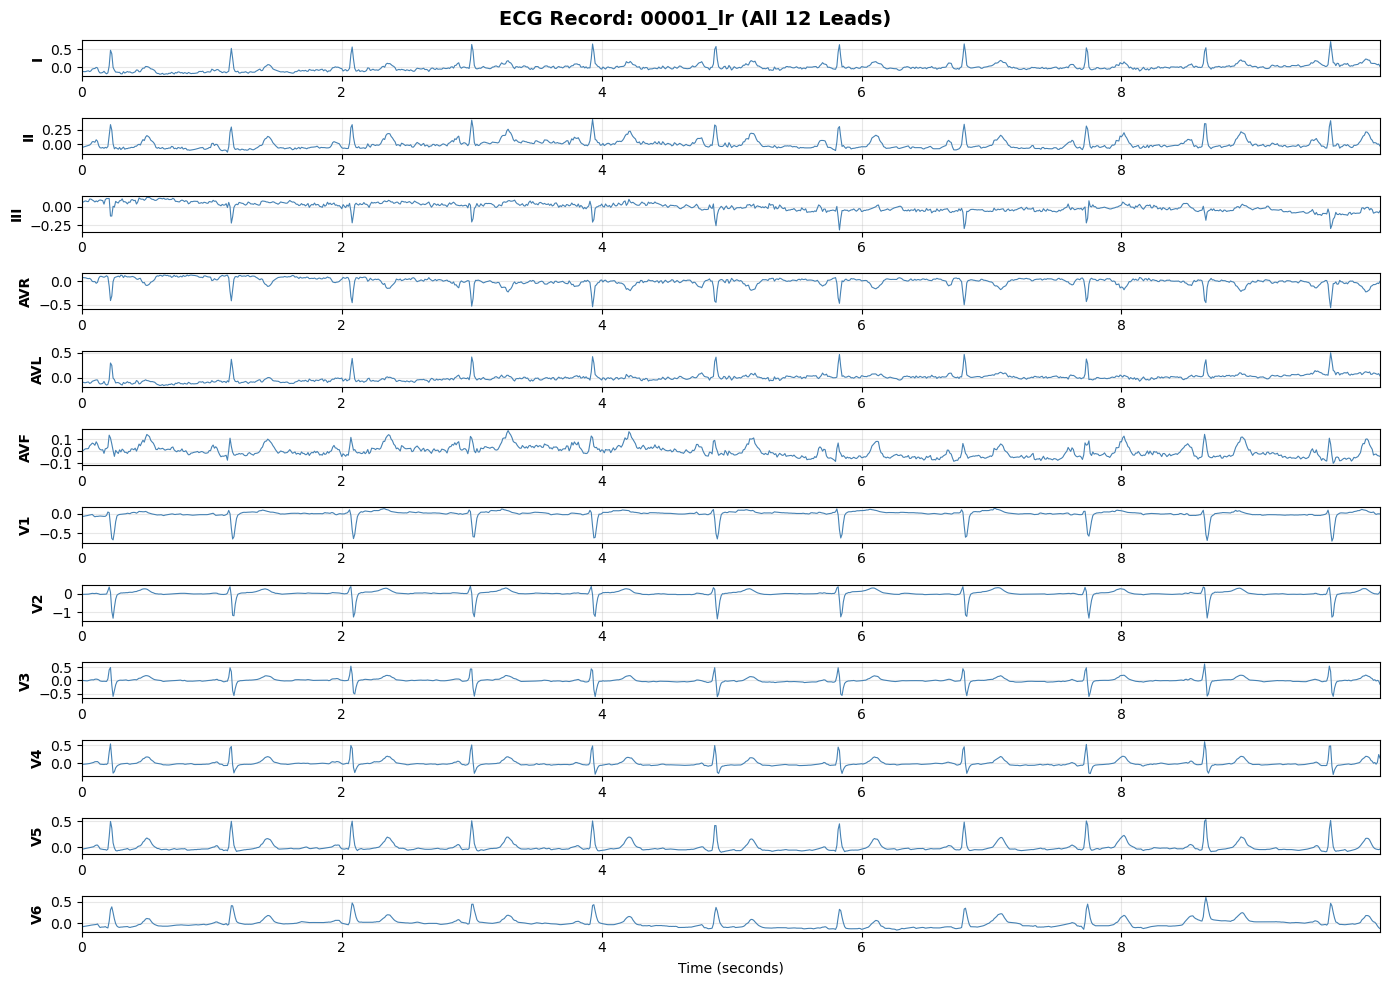

In [9]:
import numpy as np

# Plot all leads for one record
fig, axes = plt.subplots(12, 1, figsize=(14, 10))
fig.suptitle(f'ECG Record: {record_name} (All 12 Leads)', fontsize=14, fontweight='bold')

time_axis = np.arange(signal.shape[0]) / meta['fs']

for i, lead_name in enumerate(meta['sig_name']):
    axes[i].plot(time_axis, signal[:, i], linewidth=0.8, color='steelblue')
    axes[i].set_ylabel(lead_name, fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(time_axis[0], time_axis[-1])

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.show()

## Single Lead Detail

We zoom in on **Lead I** to inspect waveform morphology at a finer scale and print basic signal statistics (min, max, mean, standard deviation). This gives a feel for the amplitude range and noise level before any preprocessing or normalisation steps.

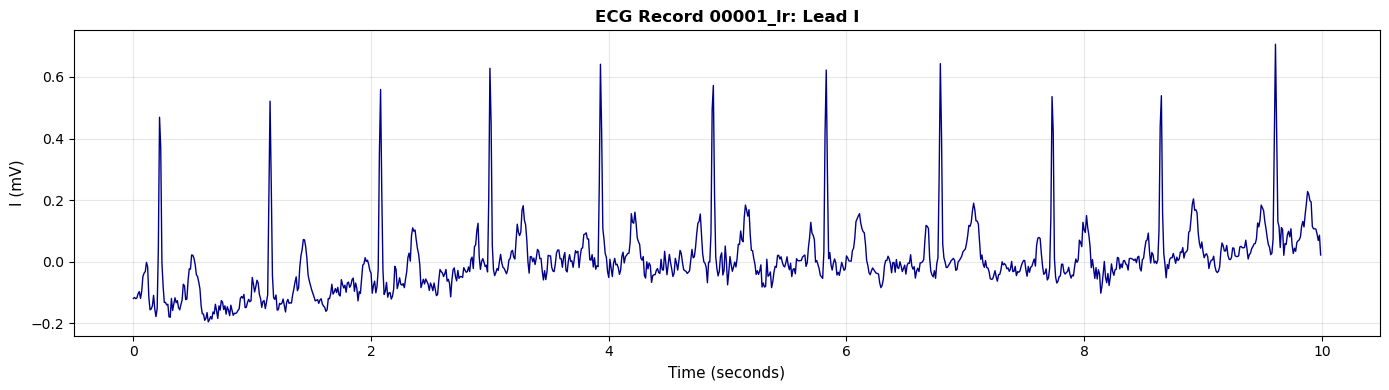


Lead I statistics:
  Min: -0.20
  Max: 0.71
  Mean: 0.00
  Std Dev: 0.11


In [10]:
# Zoom in on a single lead for detailed inspection
lead_idx = 0  # Lead I
lead_name = meta['sig_name'][lead_idx]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_axis, signal[:, lead_idx], linewidth=1, color='darkblue')
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel(f'{lead_name} ({meta["units"][lead_idx]})', fontsize=11)
ax.set_title(f'ECG Record {record_name}: Lead {lead_name}', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLead {lead_name} statistics:")
print(f"  Min: {signal[:, lead_idx].min():.2f}")
print(f"  Max: {signal[:, lead_idx].max():.2f}")
print(f"  Mean: {signal[:, lead_idx].mean():.2f}")
print(f"  Std Dev: {signal[:, lead_idx].std():.2f}")

## Normal vs. Abnormal ECG Comparison

To build intuition for what the anomaly detection model will learn, we load one **normal** record (`NORM`) and one **myocardial infarction** record (`MI`) and plot **Lead II** side by side. Lead II is commonly used for comparison because its axis aligns closely with the heart's main electrical axis, making P waves, QRS complexes, and T waves most prominent.

Differences in wave morphology, ST-segment elevation/depression, abnormal Q waves, T-wave inversion, are the clinical markers the model will need to detect.

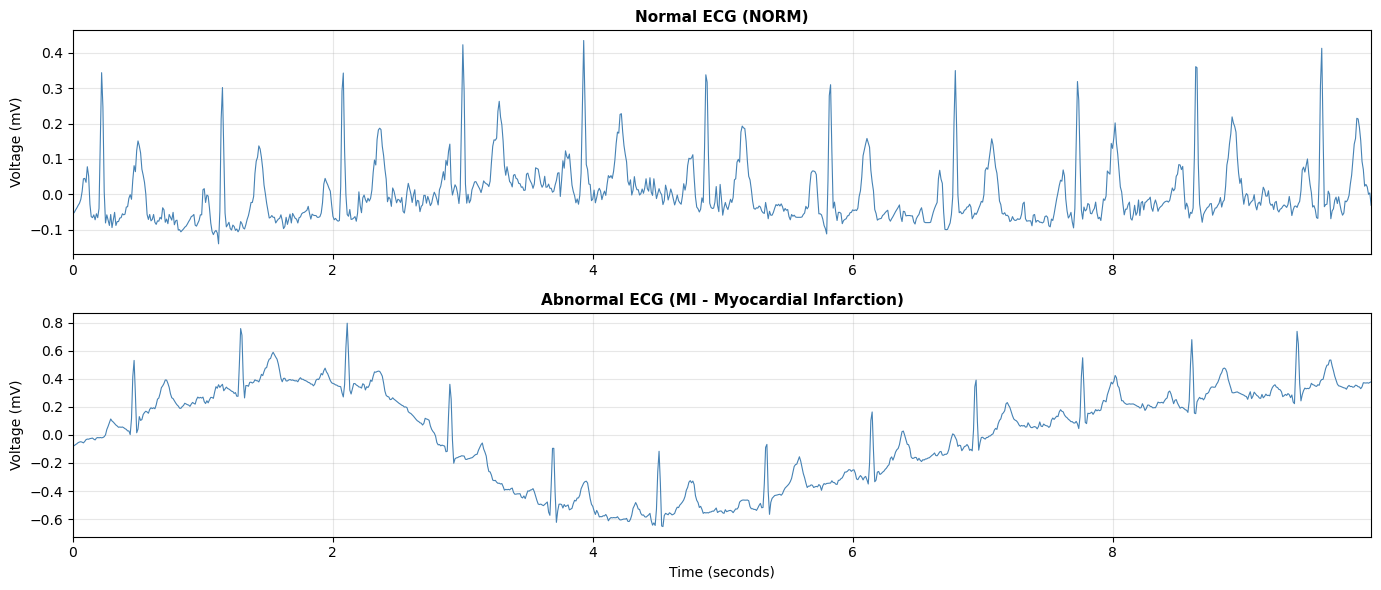

Normal record: records100/00000/00001_lr
Abnormal record: records100/00000/00008_lr


In [12]:
# Load a few records with different diagnoses
normal_record = db[db['scp_codes'].str.contains('NORM', na=False)].iloc[0]['filename_lr']
abnormal_record = db[db['scp_codes'].str.contains('MI', na=False)].iloc[0]['filename_lr']

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for idx, (rec_name, title) in enumerate([
    (normal_record, 'Normal ECG (NORM)'),
    (abnormal_record, 'Abnormal ECG (MI - Myocardial Infarction)')
]):
    rec = wfdb.rdsamp(path + rec_name)
    sig = rec[0]
    fs = rec[1]['fs']
    
    time = np.arange(sig.shape[0]) / fs
    lead_II_idx = rec[1]['sig_name'].index('II')  # Plot lead II for comparison
    
    axes[idx].plot(time, sig[:, lead_II_idx], linewidth=0.8, color='steelblue')
    axes[idx].set_ylabel('Voltage (mV)', fontsize=10)
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(time[0], time[-1])

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Normal record: {normal_record}")
print(f"Abnormal record: {abnormal_record}")